# Notebook 06 — Deep Learning Baselines on Motor Imagery

> ⚠️ **This notebook is designed to run on Kaggle, not locally.**
>
> Opening this `.ipynb` file in a local Jupyter environment will fail at the
> first cell that references `/kaggle/working/` or `/kaggle/input/`. The
> notebook depends on:
>
> - **Kaggle's free T4 GPU** (~14 minutes for EEGNet training; would be ~10
>   hours on CPU)
> - **A Kaggle Dataset** holding the preprocessed `.fif` cache from Chunk 2
>   (~2 GB, all 109 subjects)
> - **Internet access enabled** in the Kaggle notebook settings (for the
>   GitHub clone at the top)
>
> ### To reproduce this notebook
>
> 1. Open it on Kaggle: 
>    `https://www.kaggle.com/code/zidanefatuna/eegnet-for-github-com-z-bros-eeg-motorimagery`
> 2. Make a copy ("Copy & Edit") to your own Kaggle account.
> 3. In the notebook settings (right sidebar):
>    - **Accelerator:** GPU T4 x2 (or single T4)
>    - **Internet:** On
>    - **Persistence:** Files only (lets `/kaggle/working/` survive between
>      sessions if you "Save Version" at the end)
> 4. The dataset `EEG-MotorImagery preprocessed` should already be attached.
>    If not, "Add Input" and search for it on Kaggle.
> 5. Run cells top to bottom. Full reproduction (all four CV runs) takes
>    ~70 minutes of GPU time.
>
> ### Why not just run locally?
>
> - **Preprocessing (Chunks 1–5) ran locally on CPU** and is reproducible
>   on any machine. Those notebooks are in `notebooks/01..05` and use
>   standard MNE + scikit-learn dependencies — they don't need GPU.
> - **Deep learning training (this notebook) requires GPU** for practical
>   wall-clock times. Kaggle's free tier gives 30 hours/week of T4 access,
>   which is more than enough for this project's needs.
> - **Local GPU is fine if you have one** — the code itself is Kaggle-agnostic
>   except for the `/kaggle/working/` and `/kaggle/input/` paths in cells 2,
>   5, and the results-saving cells. Change those to your local paths and
>   it runs anywhere.
>
> ### What this notebook does
>
> - Loads the cached preprocessed epochs from all 109 PhysioNet motor imagery
>   subjects (Chunks 1–5 output)
> - Trains EEGNet (Lawhern 2018) and ShallowConvNet (Schirrmeister 2017) on
>   T1 (left fist imagined) vs T2 (right fist imagined) classification
> - Runs two CV regimes per architecture: 5-fold within-subject, 5-fold
>   cross-subject GroupKFold
> - Visualizes learned spatial filters as topomaps and compares to Chunk 5's
>   classical CSP filters
> - Compares results against Chunk 5's classical ML baselines (Lat, BP, CSP)
>
> ### Key findings (full details in §9)
>
> - **Within-subject ceiling (~0.57) is method-independent** — classical,
>   EEGNet, and ShallowConvNet all converge there. Sample size, not
>   architecture, is the bottleneck.
> - **Cross-subject: deep learning unlocks a 0.20–0.24 gain** over classical
>   features. ShallowConvNet 0.802, EEGNet 0.758, classical Lat 0.560.
> - **ShallowConvNet beat EEGNet by 0.044** and learned motor-cortex
>   spatial filters; EEGNet learned filters dominated by frontal-channel
>   artifact contamination, replicating Chunk 5's classical CSP failure mode.

---

# Deep Learning Baselines on Motor Imagery

EEGNet and ShallowConvNet on T1 (left fist imagined) vs T2 (right fist imagined),
runs 4/8/12, all 109 PhysioNet subjects. Full §3+§4 parity with Chunk 5's classical
pipeline (within-subject + cross-subject CV).

Chunk 5's classical baseline (median balanced_accuracy):
- Within-subject: Lat 0.580, BP 0.574, CSP 0.484
- Cross-subject:  Lat 0.560, BP 0.555, CSP 0.501

Chunk 6 asks: does deep learning move these numbers? And does the learned
spatial conv in EEGNet avoid the frontal contamination that wrecked CSP?

## 1. Setup & pre-registered predictions

**Predictions, locked before any model is trained:**

- **EEGNet cross-subject median balanced_accuracy ≥ 0.70.** This is the
  honest-methodology literature range (0.75–0.90) discounted for our specific
  setup: shorter window than Lawhern, no transfer learning, free-tier GPU.
- **EEGNet beats Lat cross-subject by ≥ 0.10** (Lat is 0.56, so ≥ 0.66).
  Weaker than (1), so it'd be a real surprise if (1) hits but (2) doesn't —
  binds the relative claim.
- **ShallowConvNet ≈ EEGNet** (within ±0.03 cross-subject median). They
  encode different inductive biases (depthwise-separable conv vs deep CSP),
  but on this small a sample they tend to converge. A large gap either way
  is informative.
- **Learned spatial filters either motor-localized or frontal-contaminated.**
  EEGNet's depthwise spatial conv is structurally analogous to CSP. If it
  learns frontal-pole filters like Chunk 5 §6's classical CSP, that's a
  damning portfolio finding: the inductive bias didn't save us. If it
  learns C3/CP3/C4/CP4 dominance, the architecture genuinely helps.

**Protocol (locked):**
- 5-fold × 1 repeat within-subject; 5-fold GroupKFold cross-subject
- Adam, lr=1e-3, batch 64, max 100 epochs, early stopping patience 15 on val balanced_accuracy
- 15% stratified inner train/val split (no test-fold leakage)
- Per-channel z-score from training fold; augmentation = channel dropout p=0.1,
  random crop to 90%, Gaussian noise σ=0.1× channel std (training only)
- Deterministic seeds, balanced class weights from training fold
- Primary metric: balanced_accuracy

In [3]:
import sys, os, subprocess, importlib, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# --- Repo path (Kaggle clones into /kaggle/working/EEG-MotorImagery) ---
REPO_ROOT = Path("/kaggle/working/EEG-MotorImagery")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# --- Confirm we're on the commit we think we are ---
commit = subprocess.run(
    ["git", "-C", str(REPO_ROOT), "rev-parse", "--short", "HEAD"],
    capture_output=True, text=True
).stdout.strip()
print(f"Repo commit: {commit}")

# --- GPU ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# --- Determinism ---
# We try strict determinism but fall back gracefully if T4 hits a kernel
# without a deterministic implementation (BN-backward edge cases).
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)
try:
    torch.use_deterministic_algorithms(True, warn_only=True)
    print("Strict determinism: enabled (warn_only=True)")
except Exception as e:
    print(f"Strict determinism unavailable: {e}")

# --- Suppress noisy MNE deprecations during data loading ---
warnings.filterwarnings("ignore", category=DeprecationWarning, module="mne")
warnings.filterwarnings("ignore", category=RuntimeWarning, module="mne")

Repo commit: 
Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
Strict determinism: enabled (warn_only=True)


In [1]:
import subprocess
import sys
from pathlib import Path

if not Path("/kaggle/working/repo").exists():
    subprocess.run(["git", "clone", "https://github.com/Z-bros/EEG-MotorImagery.git", "/kaggle/working/repo"], check=True)
sys.path.insert(0, "/kaggle/working/repo")

Cloning into '/kaggle/working/repo'...


In [2]:
from src.eegnetmods import EEGNet, ShallowConvNet, build_model
from src.torch import TorchEEGClassifier, EEGDataset, train_one_fold
from src.multisubject import (
    PIPELINE_VERSION,
    load_subject_epochs,
    _prepare_for_concat,
    _epochs_to_xy,
)

print(f"Pipeline version: {PIPELINE_VERSION}")

Pipeline version: v1


## 2. Load Chunk 5 cached data

Re-use the cached `.fif` + `_meta.json` files from Chunk 5 (uploaded as Kaggle Dataset).
Run them through `_prepare_for_concat` to interpolate bads, resample to modal sfreq
(160 Hz), and align channel order. Extract a single `(X, y, groups)` tuple for
the rest of the notebook.

Channel-count assertion: every subject ends up with 64 channels post-prepare,
or the run aborts. The deep-learning models have a fixed input shape — we
cannot tolerate a subject slipping through with a different montage.

In [4]:
# Adjust this path to wherever your Kaggle Dataset is attached.
# Typical pattern: /kaggle/input/<dataset-slug>/processed
CACHE_DIR = Path("/kaggle/input/datasets/zidanefatuna/eeg-motorimagery-preprocessed")
assert CACHE_DIR.exists(), f"Cache dir not found: {CACHE_DIR}"

# Discover available subjects from the cache directory.
subject_files = sorted(CACHE_DIR.glob("sub-*_epo.fif"))
subject_ids = [int(p.stem.split("-")[1].split("_")[0]) for p in subject_files]
print(f"Found {len(subject_ids)} subjects in cache")

# Load all epochs.
t0 = time.time()
epochs_list = []
loaded_ids = []
for sid in subject_ids:
    try:
        epochs = load_subject_epochs(sid, CACHE_DIR)
        epochs_list.append(epochs)
        loaded_ids.append(sid)
    except Exception as e:
        print(f"  sub-{sid:03d}: load failed ({e}) — skipped")
print(f"Loaded {len(epochs_list)} subjects in {time.time()-t0:.1f}s")

# Prepare for concatenation: interpolate bads, resample, align channel order.
t0 = time.time()
epochs_prepared = _prepare_for_concat(epochs_list)
print(f"Prepared in {time.time()-t0:.1f}s")

# Build (X, y, groups) once.
X_list, y_list, group_list = [], [], []
for sid, ep in zip(loaded_ids, epochs_prepared):
    Xi, yi = _epochs_to_xy(ep)
    X_list.append(Xi)
    y_list.append(yi)
    group_list.append(np.full(len(yi), sid, dtype=np.int64))

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)
groups = np.concatenate(group_list, axis=0)

# Shape contract for the deep models.
assert X.ndim == 3, f"Expected 3D X, got {X.shape}"
N_EPOCHS, N_CHANNELS, N_TIMES = X.shape
print(f"X: {X.shape}  y: {y.shape}  groups: {groups.shape}")
print(f"  n_channels = {N_CHANNELS}, n_times = {N_TIMES}")
print(f"  class balance: T1={np.sum(y==0)}, T2={np.sum(y==1)} "
      f"({np.sum(y==1)/len(y):.3f})")
print(f"  unique subjects: {len(np.unique(groups))}")

# Fail loudly if the channel count isn't what the models expect.
EXPECTED_N_CHANNELS = 64
assert N_CHANNELS == EXPECTED_N_CHANNELS, (
    f"Channel count mismatch: got {N_CHANNELS}, expected {EXPECTED_N_CHANNELS}. "
    "Check _prepare_for_concat alignment."
)

Found 109 subjects in cache
Loaded 109 subjects in 13.6s
Prepared in 3.1s
X: (4781, 64, 721)  y: (4781,)  groups: (4781,)
  n_channels = 64, n_times = 721
  class balance: T1=2408, T2=2373 (0.496)
  unique subjects: 109


## 3. Chunk 5 classical baselines (frozen comparison frame)
Median balanced_accuracy from notebook 05 (109 subjects, 5-fold × 10 repeats within-subject; 5-fold GroupKFold cross-subject). These are the numbers Chunk 6 has to beat — or fail to beat, honestly.


In [ ]:
chunk5_baselines = {
    "within": {"Lat": 0.580, "BP": 0.574, "CSP": 0.484},
    "cross":  {"Lat": 0.560, "BP": 0.555, "CSP": 0.501},
}

print("Chunk 5 baselines (median balanced_accuracy across 109 subjects):")
for regime, scores in chunk5_baselines.items():
    line = "  ".join(f"{k}={v:.3f}" for k, v in scores.items())
    print(f"  {regime:6s}  {line}")

print()
print("Best classical: Lat (lateralization indices + LogReg)")
print(f"  Within-subject median: {chunk5_baselines['within']['Lat']:.3f}")
print(f"  Cross-subject median:  {chunk5_baselines['cross']['Lat']:.3f}")
print()
print("Pre-registered Chunk 6 target: EEGNet cross-subject median >= 0.70")
print(f"  Required gain over Lat: {0.70 - chunk5_baselines['cross']['Lat']:+.3f}")

## 4. EEGNet within-subject CV

5-fold stratified CV per subject, 109 subjects = 545 fits. Each fold:
- Inside `TorchEEGClassifier.fit`: stratified 85/15 train/val split, fresh model,
  Adam lr=1e-3, balanced class weights, early stopping patience 15 on val bacc
- Test fold scored on balanced_accuracy
- Spatial filters + activations cached on the fitted classifier for §8

Smoke test first: 5 subjects to validate timing and the pipeline end-to-end.
Then full 109.

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from tqdm.auto import tqdm

# --- Smoke test toggle ---
# True  -> run on first 5 subjects only (~2 min) to validate pipeline
# False -> run on all 109 subjects (~30 min)
SMOKE_TEST = False

# --- CV config ---
N_FOLDS = 5
RANDOM_STATE = 42

# --- Output paths ---
RESULTS_DIR = Path("/kaggle/working/chunk6_results")
RESULTS_DIR.mkdir(exist_ok=True)
print(f"Results will be saved to: {RESULTS_DIR}")

# --- Subject list ---
unique_subjects = np.unique(groups)
if SMOKE_TEST:
    subjects_to_run = unique_subjects[:5]
    print(f"SMOKE TEST: {len(subjects_to_run)} subjects")
else:
    subjects_to_run = unique_subjects
    print(f"FULL RUN: {len(subjects_to_run)} subjects")

print(f"Total fits: {len(subjects_to_run) * N_FOLDS}")

In [ ]:
def run_within_subject_cv(
    model_name: str,
    X: np.ndarray, y: np.ndarray, groups: np.ndarray,
    subjects: np.ndarray,
    *,
    n_folds: int = 5,
    random_state: int = 42,
    device: str = "cuda",
    model_kwargs: dict | None = None,
) -> tuple[pd.DataFrame, dict]:
    """
    Per-subject 5-fold stratified CV. Returns:
      - per_fold_df: long-format dataframe with one row per (subject, fold)
      - filter_cache: dict {subject_id: {fold: {'spatial_filters': ndarray,
                                                'activations': ndarray}}}
    """
    rows = []
    filter_cache = {}
    n_channels = X.shape[1]
    n_times = X.shape[2]

    pbar = tqdm(subjects, desc=f"{model_name} within-subject", unit="subj")
    for sid in pbar:
        mask = (groups == sid)
        X_subj, y_subj = X[mask], y[mask]

        # Skip degenerate cases (would happen only if AutoReject killed one class)
        if len(np.unique(y_subj)) < 2 or len(y_subj) < n_folds * 2:
            print(f"  sub-{sid:03d}: skipped (insufficient class diversity or trials)")
            continue

        skf = StratifiedKFold(n_splits=n_folds, shuffle=True,
                              random_state=random_state)
        fold_scores = []
        subj_filter_cache = {}
        t_subj_start = time.time()

        for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_subj, y_subj)):
            X_tr, y_tr = X_subj[train_idx], y_subj[train_idx]
            X_te, y_te = X_subj[test_idx], y_subj[test_idx]

            clf = TorchEEGClassifier(
                model_name=model_name,
                n_channels=n_channels, n_times=n_times,
                model_kwargs=model_kwargs,
                device=device,
                random_state=random_state,
            ).set_fold_index(fold_idx)

            clf.fit(X_tr, y_tr)
            preds = clf.predict(X_te)
            bacc = balanced_accuracy_score(y_te, preds)

            rows.append({
                "subject": int(sid),
                "fold": fold_idx,
                "balanced_accuracy": bacc,
                "best_val_bacc": clf.train_result_["best_val_bacc"],
                "stopped_epoch": clf.train_result_["stopped_epoch"],
                "n_train": len(train_idx),
                "n_test": len(test_idx),
            })
            fold_scores.append(bacc)
            subj_filter_cache[fold_idx] = {
                "spatial_filters": clf.spatial_filters_,
                "activations": clf.filter_activations_,
            }

        filter_cache[int(sid)] = subj_filter_cache
        subj_time = time.time() - t_subj_start
        mean_bacc = float(np.mean(fold_scores))
        pbar.set_postfix(mean_bacc=f"{mean_bacc:.3f}")
        print(f"  sub-{sid:03d}: mean_bacc={mean_bacc:.3f}  "
              f"folds=[{','.join(f'{s:.2f}' for s in fold_scores)}]  "
              f"t={subj_time:.1f}s")

    pbar.close()
    return pd.DataFrame(rows), filter_cache

In [ ]:
t0 = time.time()
eegnet_within_df, eegnet_within_filters = run_within_subject_cv(
    model_name="eegnet",
    X=X, y=y, groups=groups,
    subjects=subjects_to_run,
    n_folds=N_FOLDS,
    random_state=RANDOM_STATE,
    device=DEVICE,
)
elapsed = time.time() - t0
print(f"\nTotal time: {elapsed:.1f}s  ({elapsed/len(subjects_to_run):.1f}s per subject)")

# --- Save per-fold results ---
suffix = "smoke" if SMOKE_TEST else "full"
out_csv = RESULTS_DIR / f"eegnet_within_{suffix}.csv"
eegnet_within_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")

# --- Save spatial filters as npz (one file, keyed by subject_fold) ---
filters_flat = {}
for sid, fold_dict in eegnet_within_filters.items():
    for fold, payload in fold_dict.items():
        filters_flat[f"sub{sid:03d}_fold{fold}_filters"] = payload["spatial_filters"]
        filters_flat[f"sub{sid:03d}_fold{fold}_acts"] = payload["activations"]
out_npz = RESULTS_DIR / f"eegnet_within_{suffix}_filters.npz"
np.savez(out_npz, **filters_flat)
print(f"Saved: {out_npz}")

# --- Per-subject summary ---
per_subject = (eegnet_within_df.groupby("subject")["balanced_accuracy"]
               .agg(["mean", "std", "min", "max"])
               .round(3))
print("\nPer-subject CV results:")
print(per_subject)
print(f"\nMedian across subjects: {per_subject['mean'].median():.3f}")
print(f"Chunk 5 Lat baseline (within): {chunk5_baselines['within']['Lat']:.3f}")

## Findings EEGNet within-subject

**Headline: EEGNet within-subject does not beat Chunk 5's lateralization baseline.**

| Metric | Chunk 5 Lat | Chunk 6 EEGNet |
|---|---|---|
| Median per-subject balanced_accuracy | 0.580 | 0.570 |
| Lift | — | -0.010 |

This was not an explicitly pre-registered prediction (we only pre-registered
cross-subject), but it would have been our implicit expectation. Logging it
as an honest negative result before §5 runs.

**Distribution (109 subjects):**
- 4 subjects (3.7%) score ≥ 0.80 — high responders
- 17 subjects (15.6%) score ≥ 0.70
- 47 subjects (43.1%) score ≥ 0.60 — broadly comparable to Chunk 5 responder rate
- 46 subjects (42.2%) score ≤ 0.55 — at chance
- Min 0.335, Max 0.835, IQR 0.530–0.645

**Subject 1 reproducibility chain holds:**
- Chunk 4 Lat accuracy: 0.67
- Chunk 5 Lat balanced_accuracy: 0.689
- Chunk 6 EEGNet balanced_accuracy: 0.720
- Smoke test (5-subject subset) and full run agree exactly at 0.720
  → deterministic seeding works

**Diagnostic: val-to-test bacc gap is large.**

| | Mean across all folds |
|---|---|
| Best val balanced_accuracy (during training) | 0.740 |
| Test fold balanced_accuracy | 0.591 |
| Gap | +0.149 |
| Folds where val exceeds test by >0.20 | 39.6% |

The model fits the inner 85/15 validation split substantially better than
the test fold generalizes. At ~45 trials/subject, the inner val slice is
only ~7 trials, giving val balanced_accuracy a granularity of ~1/7 ≈ 0.14.
Early stopping is firing on noise. This is not necessarily fixable at our
sample size — within-subject deep learning on PhysioNet motor imagery is
known to be hard for exactly this reason — but it explains why our results
plateau at the lateralization baseline.

**Early stopping behavior is otherwise healthy:**
- 0% of folds ran the full 100 epochs
- Median stop at epoch 21, mean 22.4
- 87.7% stopped at ≤ 30 epochs
  → architecture converges fast, no training pathology

**What this means for §5:**

Within-subject was the harder regime for the architecture (small N per
fit, no shared representations). Cross-subject is where deep learning's
inductive bias is supposed to pay off — single training set of ~3800 trials
per fold, ResNet-scale "lots of weakly-labeled data" regime rather than
"tiny per-subject calibration" regime.

Pre-registered prediction for §5: EEGNet cross-subject median ≥ 0.70.
Chunk 5 cross-subject Lat baseline is 0.560.

If §5 hits 0.70+, the chunk has its headline: cross-subject DL beats
classical features when within-subject DL doesn't, vindicating the
architecture's purpose. If §5 lands near §4 (~0.57), we've learned something
real about the dataset's intrinsic difficulty under honest splits.

## 5. EEGNet cross-subject CV

5-fold GroupKFold: each test fold contains a disjoint subset of subjects
(~22 subjects per fold). Train fold sees ~3800 trials from ~87 subjects;
test fold is fully held-out subjects.

This is the regime where deep learning's "lots of weakly-labeled data"
inductive bias should pay off — single training pass with shared
representation across subjects, no per-subject calibration. Chunk 5's
classical pipeline gave Lat 0.560 here; our pre-registered prediction is
EEGNet ≥ 0.70.

Spatial filters cached per fold for §8 (cross-subject filters are the
direct analog to Chunk 5 §6's population-averaged CSP analysis).

Note on the single-class-test-fold fallback in `multisubject.py`: with
22 subjects per test fold and balanced overall classes, this shouldn't
fire here — flagging only because the safety net exists in the driver.

In [ ]:
from sklearn.model_selection import GroupKFold

def run_cross_subject_cv(
    model_name: str,
    X: np.ndarray, y: np.ndarray, groups: np.ndarray,
    *,
    n_folds: int = 5,
    random_state: int = 42,
    device: str = "cuda",
    model_kwargs: dict | None = None,
) -> tuple[pd.DataFrame, dict]:
    """
    5-fold GroupKFold CV. Returns:
      - per_fold_df: one row per fold with score + diagnostics
      - filter_cache: dict {fold: {'spatial_filters': ndarray, 'activations': ndarray}}
    """
    rows = []
    filter_cache = {}
    n_channels = X.shape[1]
    n_times = X.shape[2]

    gkf = GroupKFold(n_splits=n_folds)

    for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
        X_tr, y_tr = X[train_idx], y[train_idx]
        X_te, y_te = X[test_idx], y[test_idx]
        train_subjects = np.unique(groups[train_idx])
        test_subjects = np.unique(groups[test_idx])

        print(f"\n--- Fold {fold_idx} ---")
        print(f"  train: {len(X_tr)} trials, {len(train_subjects)} subjects")
        print(f"  test:  {len(X_te)} trials, {len(test_subjects)} subjects "
              f"({test_subjects.min()}..{test_subjects.max()})")
        print(f"  test class balance: T1={np.sum(y_te==0)} T2={np.sum(y_te==1)}")

        t_fold_start = time.time()
        clf = TorchEEGClassifier(
            model_name=model_name,
            n_channels=n_channels, n_times=n_times,
            model_kwargs=model_kwargs,
            device=device,
            random_state=random_state,
        ).set_fold_index(fold_idx)

        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_te)

        # Test-fold metrics
        bacc = balanced_accuracy_score(y_te, preds)

        # Per-subject test scores within this fold (for fold-internal variance)
        per_subj_scores = []
        for sid in test_subjects:
            mask = (groups[test_idx] == sid)
            if mask.sum() >= 2 and len(np.unique(y_te[mask])) == 2:
                per_subj_scores.append(
                    balanced_accuracy_score(y_te[mask], preds[mask]))
        per_subj_mean = float(np.mean(per_subj_scores)) if per_subj_scores else np.nan
        per_subj_median = float(np.median(per_subj_scores)) if per_subj_scores else np.nan

        fold_time = time.time() - t_fold_start

        rows.append({
            "fold": fold_idx,
            "balanced_accuracy": bacc,
            "per_subj_mean_bacc": per_subj_mean,
            "per_subj_median_bacc": per_subj_median,
            "n_test_subjects": len(test_subjects),
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            "best_val_bacc": clf.train_result_["best_val_bacc"],
            "stopped_epoch": clf.train_result_["stopped_epoch"],
            "fold_time_s": round(fold_time, 1),
        })
        filter_cache[fold_idx] = {
            "spatial_filters": clf.spatial_filters_,
            "activations": clf.filter_activations_,
            "train_subjects": train_subjects.tolist(),
            "test_subjects": test_subjects.tolist(),
        }

        print(f"  test bacc: {bacc:.3f}  (per-subj mean: {per_subj_mean:.3f}, "
              f"median: {per_subj_median:.3f})")
        print(f"  val bacc:  {clf.train_result_['best_val_bacc']:.3f}  "
              f"stopped at epoch {clf.train_result_['stopped_epoch']}")
        print(f"  fold time: {fold_time:.1f}s")

    return pd.DataFrame(rows), filter_cache

In [ ]:
t0 = time.time()
eegnet_cross_df, eegnet_cross_filters = run_cross_subject_cv(
    model_name="eegnet",
    X=X, y=y, groups=groups,
    n_folds=N_FOLDS,
    random_state=RANDOM_STATE,
    device=DEVICE,
)
elapsed = time.time() - t0
print(f"\nTotal time: {elapsed:.1f}s")

# --- Save ---
out_csv = RESULTS_DIR / "eegnet_cross_full.csv"
eegnet_cross_df.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")

# Filters as npz, one entry per fold
filters_flat = {}
for fold, payload in eegnet_cross_filters.items():
    filters_flat[f"fold{fold}_filters"] = payload["spatial_filters"]
    filters_flat[f"fold{fold}_acts"] = payload["activations"]
out_npz = RESULTS_DIR / "eegnet_cross_full_filters.npz"
np.savez(out_npz, **filters_flat)
print(f"Saved: {out_npz}")

# --- Summary ---
print("\nPer-fold results:")
print(eegnet_cross_df[["fold", "balanced_accuracy", "per_subj_mean_bacc",
                       "per_subj_median_bacc", "stopped_epoch",
                       "fold_time_s"]].to_string(index=False))

trial_pooled_median = eegnet_cross_df["balanced_accuracy"].median()
per_subj_median_of_medians = eegnet_cross_df["per_subj_median_bacc"].median()
print(f"\nCross-subject EEGNet:")
print(f"  Trial-pooled bacc median across folds: {trial_pooled_median:.3f}")
print(f"  Per-subject median (median of fold-internal medians): "
      f"{per_subj_median_of_medians:.3f}")
print(f"  Chunk 5 Lat cross-subject baseline:    {chunk5_baselines['cross']['Lat']:.3f}")
print(f"  Pre-registered target (≥):             0.700")

## 6. ShallowConvNet within-subject CV

Same protocol as §4, different architecture. ShallowConvNet (Schirrmeister
2017) is conceptually a "deep CSP" — temporal conv + spatial conv + square +
log-pool, the differentiable analog of CSP's log-variance features. ~107K params
at our window size.

Pre-registered prediction (§1, prediction 3): Shallow ≈ EEGNet ±0.03.
On cross-subject, this means Shallow ∈ [0.728, 0.788].
On within-subject (not explicitly pre-registered): expect ≈ 0.57, same regime
as EEGNet given the sample-size constraint.

In [ ]:
t0 = time.time()
shallow_within_df, shallow_within_filters = run_within_subject_cv(
    model_name="shallow",
    X=X, y=y, groups=groups,
    subjects=unique_subjects,
    n_folds=N_FOLDS,
    random_state=RANDOM_STATE,
    device=DEVICE,
)
elapsed = time.time() - t0
print(f"\nTotal time: {elapsed:.1f}s  ({elapsed/len(unique_subjects):.1f}s per subject)")

# Save
shallow_within_df.to_csv(RESULTS_DIR / "shallow_within_full.csv", index=False)
filters_flat = {}
for sid, fold_dict in shallow_within_filters.items():
    for fold, payload in fold_dict.items():
        filters_flat[f"sub{sid:03d}_fold{fold}_filters"] = payload["spatial_filters"]
        filters_flat[f"sub{sid:03d}_fold{fold}_acts"] = payload["activations"]
np.savez(RESULTS_DIR / "shallow_within_full_filters.npz", **filters_flat)
print(f"Saved: shallow_within_full.csv + shallow_within_full_filters.npz")

# Summary
per_subj = shallow_within_df.groupby("subject")["balanced_accuracy"].agg(["mean", "std"]).round(3)
shallow_within_median = per_subj["mean"].median()
print(f"\nShallowConvNet within-subject median: {shallow_within_median:.3f}")
print(f"EEGNet within-subject median (§4):    0.570")
print(f"Chunk 5 Lat within-subject baseline:  {chunk5_baselines['within']['Lat']:.3f}")
print(f"\nResponders (mean_bacc >= 0.60): {(per_subj['mean'] >= 0.60).sum()}/{len(per_subj)}")
print(f"At chance (mean_bacc <= 0.55):  {(per_subj['mean'] <= 0.55).sum()}/{len(per_subj)}")

# Subject 1 reproducibility for the Shallow chain
s1 = per_subj.loc[1, "mean"]
print(f"\nSubject 1 Shallow within-subject: {s1:.3f}")
print(f"  EEGNet was 0.720 — same architecture family, expect similar but not identical")

## 7. ShallowConvNet cross-subject CV

Same protocol as §5. ±3000 training trials per fold, 5 GroupKFold splits.
Per-fold time will be longer than EEGNet's ±150s due to the larger parameter
count (±107K vs EEGNet's ±2.8K). Total estimate: 15-25 minutes.

This is the prediction-3 test: Shallow ≈ EEGNet ±0.03 on cross-subject.
EEGNet hit 0.758. Shallow target band: 0.728–0.788.

In [ ]:
t0 = time.time()
shallow_cross_df, shallow_cross_filters = run_cross_subject_cv(
    model_name="shallow",
    X=X, y=y, groups=groups,
    n_folds=N_FOLDS,
    random_state=RANDOM_STATE,
    device=DEVICE,
)
elapsed = time.time() - t0
print(f"\nTotal time: {elapsed:.1f}s")

# Save
shallow_cross_df.to_csv(RESULTS_DIR / "shallow_cross_full.csv", index=False)
filters_flat = {}
for fold, payload in shallow_cross_filters.items():
    filters_flat[f"fold{fold}_filters"] = payload["spatial_filters"]
    filters_flat[f"fold{fold}_acts"] = payload["activations"]
np.savez(RESULTS_DIR / "shallow_cross_full_filters.npz", **filters_flat)
print(f"Saved: shallow_cross_full.csv + shallow_cross_full_filters.npz")

# Summary
print("\nPer-fold results:")
print(shallow_cross_df[["fold", "balanced_accuracy", "per_subj_mean_bacc",
                        "per_subj_median_bacc", "stopped_epoch",
                        "fold_time_s"]].to_string(index=False))

shallow_trial_median = shallow_cross_df["balanced_accuracy"].median()
shallow_subj_median = shallow_cross_df["per_subj_median_bacc"].median()
eegnet_subj_median = 0.758  # from §5

print(f"\nShallowConvNet cross-subject:")
print(f"  Trial-pooled bacc median:           {shallow_trial_median:.3f}")
print(f"  Subject-pooled median:              {shallow_subj_median:.3f}")
print(f"  EEGNet cross-subject (§5):          {eegnet_subj_median:.3f}")
print(f"  Difference (Shallow - EEGNet):      {shallow_subj_median - eegnet_subj_median:+.3f}")
print(f"  Pre-registered band (Shallow ± EEGNet 0.03): "
      f"[{eegnet_subj_median - 0.03:.3f}, {eegnet_subj_median + 0.03:.3f}]")
print(f"  Prediction 3 outcome: "
      f"{'MET' if abs(shallow_subj_median - eegnet_subj_median) <= 0.03 else 'MISSED'}")

## Findings: architecture comparison consolidated

**Three-method summary, balanced_accuracy median across 109 subjects:**

| | Within-subject | Cross-subject |
|---|---|---|
| Chunk 5 Lat (classical) | 0.580 | 0.560 |
| EEGNet | 0.570 | 0.758 |
| ShallowConvNet | 0.565 | **0.802** |

**Within-subject: the sample-size ceiling is architecture-agnostic.**

All three methods cluster at 0.57–0.58. ShallowConvNet's ~107K parameters
trained on ~36 trials per fold do not outperform EEGNet's ~2,800 parameters
on the same data, and neither outperforms a classical lateralization-index
feature with a logistic regression head. This is now a robust three-method
finding, not a one-architecture quirk. At this sample size, the data
genuinely does not support deep-learning gains — the §4 val-to-test gap
diagnosis (early stopping firing on a 7-trial val set) applies equally to
Shallow. We did *not* pre-register a within-subject prediction here, but
informally we'd have expected DL to help. It does not.

**Cross-subject: architecture matters and Shallow wins.**

| Architecture | Cross-subject median | vs Lat baseline | vs prev row |
|---|---|---|---|
| Lat | 0.560 | — | — |
| EEGNet | 0.758 | +0.198 | — |
| ShallowConvNet | 0.802 | +0.242 | +0.044 |

Shallow exceeds EEGNet by 0.044, just outside our pre-registered ±0.03 band.
Crucially, *every one* of Shallow's 5 folds (range 0.741–0.821) exceeds the
trial-pooled median of EEGNet, so this isn't a one-fold artifact.

**Interpretation: inductive bias as a design lever.**

The architectures differ in what they assume about EEG. EEGNet's design
(depthwise-separable temporal + spatial + linear) is general — it assumes
a temporal-then-spatial decomposition but is otherwise architecturally
agnostic about *what* the features mean. ShallowConvNet's design (temporal
conv → spatial conv → square → log-pool) is the differentiable analog of
CSP's log-variance feature: it bakes in the assumption that band power is
what matters.

For motor imagery, the log-variance assumption is *correct*. Mu (10–13 Hz)
and beta (15–25 Hz) band power desynchronization over sensorimotor cortex
is the textbook signature, and Chunk 3 confirmed it in the cue-evoked TFR.
Shallow gets this assumption for free; EEGNet has to discover it through
gradient descent. At 3,000 training trials, Shallow's stronger inductive
bias converts to a 4.4-point accuracy advantage.

**This sharpens the §8 question.**

Chunk 5 §6 found classical CSP failed because its spatial filters localized
to frontal-pole sites (Fp1, Fp2, F7, F8, T8) rather than motor cortex
(C3, C4) — residual EMG/oculomotor contamination that survived ICA. The
"deep CSP" structure of ShallowConvNet succeeded where classical CSP
failed. Did Shallow succeed by avoiding the frontal contamination? Or
did it succeed despite picking up the same frontal noise, because gradient
descent on 3,000 trials regularizes more effectively than CSP's
eigendecomposition on per-subject samples?

§8 will answer this directly by topomap-visualizing the learned spatial
filters from both Shallow and EEGNet against the classical CSP filters
from Chunk 5 §6.

**Prediction tally so far:**

| # | Prediction | Outcome |
|---|---|---|
| 1 | EEGNet cross-subject ≥ 0.70 | ✅ 0.758 |
| 2 | EEGNet beats Lat cross-subject by ≥ 0.10 | ✅ +0.198 |
| 3 | Shallow ≈ EEGNet ±0.03 cross-subject | ❌ +0.044, Shallow won |
| 4 | Learned spatial filters motor-localized or frontal-contaminated | (§8) |

## 8. Learned spatial filter topomaps

The headline §6+§7 finding was that ShallowConvNet (cross-subject 0.802) beats
EEGNet (0.758) which beats classical Lat (0.560). The "deep CSP" structure of
Shallow succeeded where classical CSP failed in Chunk 5 (median 0.501, with §6
showing its spatial filters localized to frontal-pole/anterior-temporal sites:
Fp1, Fp2, F7, F8, T8 — residual EMG/oculomotor artifact).

The question for §8: did Shallow succeed by learning *motor-localized* filters,
or by tolerating the same frontal contamination through gradient-descent
regularization?

**Comparison frame (textual, no direct overlay):**
Chunk 5 §6's population-averaged classical CSP filters localized to:
- Frontal pole: Fp1, Fp2 (signature of residual EOG)
- Anterior temporal: F7, F8, T8 (signature of residual EMG)
- NOT C3/C4 or surrounding sensorimotor sites

If §8 shows EEGNet/Shallow filters peaking over FC3/FC4, C3/C4, or CP3/CP4,
that's a cleaner spatial localization than classical CSP achieved — and would
explain the architecture-vs-algorithm performance gap. If §8 shows the same
frontal contamination, then the performance gap comes from somewhere else
entirely (e.g., the squaring nonlinearity, the temporal filter learning).

In [ ]:
import mne
from src.multisubject import load_subject_epochs

# Get a representative info object from any loaded subject.
# All subjects share the same montage post-_prepare_for_concat.
_ref_epochs = epochs_prepared[0]
info = _ref_epochs.info
assert len(info["ch_names"]) == N_CHANNELS, (
    f"Info has {len(info['ch_names'])} channels, expected {N_CHANNELS}")
print(f"Reference info: {len(info['ch_names'])} channels, "
      f"montage = {info.get_montage().__class__.__name__ if info.get_montage() else 'none'}")


def sign_align_and_average(filters_per_fold: list[np.ndarray]) -> np.ndarray:
    """
    Average spatial filters across folds with sign alignment.

    Each spatial conv filter has an arbitrary sign (the network can flip the
    filter and the corresponding next-layer weight without changing output).
    Naive averaging across folds would cancel. We anchor on fold 0's sign and
    flip any filter from later folds whose correlation with fold 0's
    counterpart is negative.

    filters_per_fold : list of arrays, each (n_filters, n_channels)
    Returns : array (n_filters, n_channels), the sign-aligned average.
    """
    stacked = np.stack(filters_per_fold, axis=0)  # (n_folds, n_filters, n_channels)
    anchor = stacked[0]  # (n_filters, n_channels)

    aligned = stacked.copy()
    for fold_idx in range(1, stacked.shape[0]):
        for filt_idx in range(stacked.shape[1]):
            corr = np.dot(stacked[fold_idx, filt_idx], anchor[filt_idx])
            if corr < 0:
                aligned[fold_idx, filt_idx] *= -1.0

    return aligned.mean(axis=0)

In [ ]:
# --- EEGNet: load filter cache from the .npz (already loaded in memory as
#     eegnet_cross_filters, but we'll reload from disk to be explicit) ---

eegnet_filters_per_fold = []  # each is (16, 64)
eegnet_acts_per_fold = []     # each is (16,)
for fold in range(N_FOLDS):
    eegnet_filters_per_fold.append(eegnet_cross_filters[fold]["spatial_filters"])
    eegnet_acts_per_fold.append(eegnet_cross_filters[fold]["activations"])

eegnet_avg_filters = sign_align_and_average(eegnet_filters_per_fold)
eegnet_avg_acts = np.stack(eegnet_acts_per_fold, axis=0).mean(axis=0)

print(f"EEGNet avg filters: {eegnet_avg_filters.shape}, "
      f"avg activations: {eegnet_avg_acts.shape}")

# --- ShallowConvNet: filters are (40, 40, 64). Aggregate over the temporal-
#     filter axis first (axis=1), then sign-align and average across folds. ---

shallow_filters_per_fold = []
shallow_acts_per_fold = []
for fold in range(N_FOLDS):
    raw = shallow_cross_filters[fold]["spatial_filters"]  # (40, 40, 64)
    # Aggregate over temporal-filter axis. Mean is sign-sensitive (sign
    # ambiguity within filter pairs); RMS captures spatial energy regardless
    # of sign. RMS is the cleaner aggregation for "where does this filter
    # attend on the scalp."
    spatial_only = np.sqrt((raw ** 2).mean(axis=1))  # (40, 64)
    shallow_filters_per_fold.append(spatial_only)
    shallow_acts_per_fold.append(shallow_cross_filters[fold]["activations"])

# Note: because we used RMS, all values are non-negative — sign-alignment
# is a no-op but we still call the function for symmetry / safety.
shallow_avg_filters = sign_align_and_average(shallow_filters_per_fold)
shallow_avg_acts = np.stack(shallow_acts_per_fold, axis=0).mean(axis=0)

print(f"Shallow avg filters: {shallow_avg_filters.shape}, "
      f"avg activations: {shallow_avg_acts.shape}")

# --- Pick top 6 by activation for each architecture ---
TOP_K = 6
eegnet_topk = np.argsort(eegnet_avg_acts)[-TOP_K:][::-1]  # descending
shallow_topk = np.argsort(shallow_avg_acts)[-TOP_K:][::-1]

print(f"\nEEGNet top-{TOP_K} filter indices (most activated): {eegnet_topk}")
print(f"  activations: {eegnet_avg_acts[eegnet_topk].round(3)}")
print(f"Shallow top-{TOP_K} filter indices (most activated): {shallow_topk}")
print(f"  activations: {shallow_avg_acts[shallow_topk].round(3)}")

In [ ]:
fig, axes = plt.subplots(2, TOP_K, figsize=(3 * TOP_K, 6.5))

# Row 0: EEGNet
for col, filt_idx in enumerate(eegnet_topk):
    weights = eegnet_avg_filters[filt_idx]
    im, _ = mne.viz.plot_topomap(
        weights, info, axes=axes[0, col], show=False,
        cmap="RdBu_r", sensors=True, contours=4,
    )
    axes[0, col].set_title(
        f"EEGNet f{filt_idx}\n(act={eegnet_avg_acts[filt_idx]:.2f})",
        fontsize=10)

# Row 1: Shallow
for col, filt_idx in enumerate(shallow_topk):
    weights = shallow_avg_filters[filt_idx]
    im, _ = mne.viz.plot_topomap(
        weights, info, axes=axes[1, col], show=False,
        cmap="Reds", sensors=True, contours=4,  # Reds because RMS is >=0
    )
    axes[1, col].set_title(
        f"Shallow f{filt_idx}\n(act={shallow_avg_acts[filt_idx]:.2f})",
        fontsize=10)

# Row labels on the leftmost subplot of each row
axes[0, 0].set_ylabel("EEGNet\n(signed weights)", fontsize=11, rotation=90,
                     labelpad=15)
axes[1, 0].set_ylabel("ShallowConvNet\n(RMS over temporal filters)",
                     fontsize=11, rotation=90, labelpad=15)

fig.suptitle("Top-6 cross-subject spatial filters by training activation\n"
             "(sign-aligned and averaged across 5 GroupKFold folds)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "spatial_filters_topomaps.png",
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / 'spatial_filters_topomaps.png'}")

In [ ]:
# Programmatic check: which channels dominate each filter's magnitude?
# Compare to motor-cortex channels (the ones we'd predict are discriminative
# for left-vs-right imagined fist) and frontal/temporal channels (the ones
# Chunk 5 §6 found contaminated classical CSP).

MOTOR_CHANNELS = ["C3", "C4", "Cz", "FC3", "FC4", "FCz",
                  "CP3", "CP4", "CPz", "C1", "C2", "C5", "C6"]
FRONTAL_CHANNELS = ["Fp1", "Fp2", "AF3", "AF4", "AF7", "AF8",
                    "F7", "F8", "F5", "F6", "FT7", "FT8"]
TEMPORAL_CHANNELS = ["T7", "T8", "TP7", "TP8"]

ch_names = info["ch_names"]

def localization_report(filters: np.ndarray, top_idx: np.ndarray,
                        label: str) -> None:
    print(f"\n{label} top-{len(top_idx)} filter localization:")
    print(f"  (% of total |weight| concentrated in each ROI)")
    print(f"  {'filter':>8s}  {'motor':>8s}  {'frontal':>8s}  "
          f"{'temporal':>8s}  {'top-3 channels':>20s}")
    for fi in top_idx:
        w = np.abs(filters[fi])
        total = w.sum() + 1e-12
        motor_pct = sum(w[ch_names.index(c)] for c in MOTOR_CHANNELS
                        if c in ch_names) / total
        front_pct = sum(w[ch_names.index(c)] for c in FRONTAL_CHANNELS
                        if c in ch_names) / total
        temp_pct  = sum(w[ch_names.index(c)] for c in TEMPORAL_CHANNELS
                        if c in ch_names) / total
        top3 = [ch_names[i] for i in np.argsort(w)[-3:][::-1]]
        print(f"  {fi:>8d}  {motor_pct:>7.1%}  {front_pct:>7.1%}  "
              f"{temp_pct:>7.1%}  {','.join(top3):>20s}")

localization_report(eegnet_avg_filters, eegnet_topk, "EEGNet")
localization_report(shallow_avg_filters, shallow_topk, "ShallowConvNet")

print("\n--- Comparison ---")
print("Chunk 5 §6 classical CSP: dominated by Fp1, Fp2, F7, F8, T8")
print("Motor ROI (expected for true T1/T2 discrimination): C3, C4, FC3, FC4, CP3, CP4")

## Findings: ShallowConvNet learns motor-localized filters; EEGNet does not

**The visual topomaps and the quantitative localization tell different stories.**
EEGNet's filters show clean dipolar patterns; ShallowConvNet's RMS-aggregated
maps look diffuse. But the quantitative breakdown reveals the opposite of what
the visual impression suggests.

### Localization breakdown (% of total |weight| in each ROI)

| | EEGNet top-6 | ShallowConvNet top-6 |
|---|---|---|
| Motor ROI (C3, C4, FCx, CPx, Cx) | ~17% | **~22%** |
| Frontal ROI (Fp, AF, F-anterior) | **~28%** | ~18% |
| Temporal ROI (T7, T8, TPx) | ~6% | ~7% |
| Dominant top-3 channels | F8, AF8, F7, FT7 (frontal/anterior-temporal) | C3, C1, CP3, CP4, FCz (motor) |

### EEGNet replicates classical CSP's failure mode

Every one of EEGNet's top-6 most-activated cross-subject filters has at least
one frontal-pole or anterior-frontal channel (F7, F8, AF8, AF7, FT7) in its
top-3 channels. Only filter 4 contains a motor channel (CP1) in its top-3.
The pattern is structurally identical to Chunk 5 §6's finding that classical
CSP filters localized to Fp1, Fp2, F7, F8, T8.

This is shortcut learning. EEGNet's depthwise spatial conv has no inductive
bias about *where* on the scalp the discriminative signal should live — it
finds whatever correlates with label. Residual EMG/oculomotor activity that
survived 20-component ICA apparently does correlate with imagined-left vs
imagined-right (anticipatory eye movement, frontal alpha asymmetry, or jaw
tension differing by motor-imagery laterality), and EEGNet exploits it.
The 0.758 accuracy is partly real motor signal, but partly artifact.

### ShallowConvNet's inductive bias rescues it

ShallowConvNet's top-6 filters concentrate weight in motor-strip channels:
C3, C1, CP3, CP4, C4, FCz. The `square → log → average pool` structure forces
the network to operate on band power, not raw signal. Broadband EMG and DC
drift get suppressed by the bandpass-then-log-variance computation; tight-band
mu/beta desynchronization survives. The architecture's domain assumption
("this dataset's information lives in log band power") steers it toward
neuronal oscillations rather than artifact channels.

### Connecting the dots to §7's accuracy advantage

ShallowConvNet's 0.044 advantage over EEGNet on cross-subject (0.802 vs 0.758)
is not just a numerical win — it's a *quality* win. Shallow is solving the
task using the features the protocol was designed to elicit (mu/beta ERD/ERS
over sensorimotor cortex). EEGNet is solving the task partly by exploiting
correlated artifact. On a held-out dataset with different recording conditions
or after stronger artifact removal, EEGNet's edge over baseline would likely
shrink more than Shallow's would.

### Caveats and methodological footnotes

- **RMS aggregation visually obscures Shallow's dipolar structure.** The
  flat-red topomaps for Shallow are an aggregation artifact (RMS over 40
  temporal filters collapses signed dipoles to positive magnitudes). The
  underlying signed filters do show C3-vs-C4 lateralization in individual
  `(temporal, spatial)` slices, but visualizing 1,600 such slices isn't
  tractable. The quantitative localization percentages are the truth.
- **Iz appearing in 4 of 6 Shallow filter top-3s** is suspicious — it's a
  posterior midline site that's mechanically far from motor cortex. Likely
  reflects a quirk of how the RMS aggregation handles spatial extremes
  rather than a real finding. Worth a follow-up in the "parked" list, not
  in this notebook.
- **EEGNet's frontal contamination is a feature of *this* dataset, not the
  architecture per se.** Trained on a dataset with cleaner ICA or different
  artifact distribution, EEGNet might localize cleanly. The finding is
  conditional: "on PhysioNet motor imagery with 20-component ICA, EEGNet
  picks up residual frontal artifacts."

### Prediction 4 resolved

> Pre-registered: "Learned spatial filters either motor-localized or
> frontal-contaminated."

The pre-registration treated this as a binary. Reality is more interesting:
**EEGNet frontal-contaminated, ShallowConvNet motor-localized.** Both
architectures predicted, both outcomes observed, in the same data, with the
same cross-validation split. The split outcome is what makes the §7
accuracy gap *physiologically meaningful* rather than just a number.

### Prediction tally (final)

| # | Prediction | Outcome |
|---|---|---|
| 1 | EEGNet cross-subject ≥ 0.70 | ✅ 0.758 |
| 2 | EEGNet beats Lat cross-subject by ≥ 0.10 | ✅ +0.198 |
| 3 | Shallow ≈ EEGNet ±0.03 cross-subject | ❌ +0.044, Shallow won |
| 4 | Filters motor-localized or frontal-contaminated | ✅ Split: Shallow motor, EEGNet frontal |

## 9. Summary: predictions, results, and the narrative arc

### Pre-registered predictions vs. actuals

All four predictions were registered in §1 before any model was trained, in
this notebook's first cell. Outcomes:

| # | Prediction | Result | Outcome |
|---|---|---|---|
| 1 | EEGNet cross-subject median balanced_accuracy ≥ 0.70 | 0.758 | ✅ Met |
| 2 | EEGNet beats Chunk 5 Lat cross-subject by ≥ 0.10 | +0.198 (0.758 vs 0.560) | ✅ Met |
| 3 | ShallowConvNet ≈ EEGNet within ±0.03 cross-subject | +0.044 (Shallow > EEGNet) | ❌ Missed |
| 4 | Learned spatial filters motor-localized or frontal-contaminated | Split outcome | ✅ Resolved |

Three of four resolved as predicted; one (prediction 3) missed in an
informative direction — ShallowConvNet's stronger inductive bias gave it a
real advantage over EEGNet's more general architecture. Prediction 4 had
been registered as a binary, but the result was split: ShallowConvNet
learned motor-localized filters, EEGNet replicated classical CSP's
frontal-contamination failure mode.

### The headline numbers (median balanced_accuracy, 109 subjects)

| Method | Within-subject | Cross-subject | Source |
|---|---|---|---|
| Random chance | 0.500 | 0.500 | — |
| Lateralization + LogReg | 0.580 | 0.560 | Chunk 5 |
| Band power + LinearSVC | 0.574 | 0.555 | Chunk 5 |
| Classical CSP + LDA | 0.484 | 0.501 | Chunk 5 |
| EEGNet | 0.570 | 0.758 | Chunk 6 §4 + §5 |
| ShallowConvNet | 0.565 | **0.802** | Chunk 6 §6 + §7 |

ShallowConvNet cross-subject is the chunk's best result. Within-subject
results cluster around 0.57 for all five methods — the sample-size ceiling
at ~45 trials per subject is method-independent.

### The narrative arc (Chunk 4 → 5 → 6)

Each chunk made one core finding that shaped the next:

**Chunk 4 (single-subject classical):** The discriminative signal for T1 vs T2
on subject 1 lives over FC3/FC4 mu and CP3/CP4 beta, not the canonical
C3/C4 sites. Lateralization indices outperformed CSP at single-subject
scale because CSP overfit on 36 trials; the diagnostic confirmed CSP's
weights were partly driven by frontal/temporal artifact (Fp1, T8, F8).

**Chunk 5 (classical at population scale):** The Chunk 4 single-subject CSP
contamination generalized — population-averaged CSP filters across 109
subjects localized to frontal-pole and anterior-temporal sites, not motor
cortex. Cross-subject classical ML topped out at 0.560 (Lat). The
within-vs-cross gap was small (~0.02), masking substantial per-subject
restructuring: 34% of subjects performed worse under pooling, 19% better.

**Chunk 6 (deep learning at population scale):**
- The within-subject ceiling held: 0.57 for all methods. EEGNet's parameter
  count couldn't help; ShallowConvNet's larger network didn't either.
  Confirms the ceiling is *data*, not architecture.
- Cross-subject changed dramatically. Deep learning unlocked a
  +0.20 to +0.24 gain over the best classical baseline. ShallowConvNet's
  "deep CSP" architecture beat EEGNet's general convolutional design by
  +0.044, vindicating the log-variance inductive bias that classical CSP
  also used.
- §8 spatial-filter analysis revealed *why* ShallowConvNet won: it learned
  motor-cortex filters (C3, C1, CP3, CP4, FCz, C4 dominating top-6 by
  activation). EEGNet, with no domain-informed structure, learned filters
  dominated by frontal-contamination channels (F8, AF8, F7, FT7, AF7),
  the same contamination that wrecked classical CSP.

The clean story across the three chunks: **with classical features, signal
was too weak to overcome heterogeneity. With deep learning and 3,000 training
trials per fold, the right inductive bias (Shallow's band-power architecture)
produced clean motor-cortex localization and 0.80 accuracy. The wrong
inductive bias (EEGNet's general design) produced 0.76 accuracy by
exploiting artifact correlations with label — accurate but for the wrong
reasons.**

### Parked follow-ups (from the original Chunk 6 plan + new ones from §8)

From the project brief, still parked:

- Tightened ICA targeting EMG/oculomotor components, motivated by Chunk 5 §6
  and now sharpened by §8's EEGNet finding. Would test whether reducing
  artifact contamination closes the EEGNet-vs-ShallowConvNet gap.
- Recovery of IC rejection indices from Chunk 2 wrapper for IC-vs-spatial-
  filter cross-reference analyses.
- pyprep migration for bad-channel detection.
- Memory-efficient nested CV for population-scale hyperparameter tuning.
- Filter-bank CSP and Riemannian features (permanently parked).
- Individual `(temporal, spatial)` slice visualization of ShallowConvNet
  filters to recover the dipolar structure that RMS aggregation collapsed.
  Would produce cleaner §8 topomaps for the portfolio.
- The Iz-dominance anomaly in Shallow filter top-3 channels. Probably an
  aggregation artifact, but worth verifying.
- Transfer learning (pre-train cross-subject, fine-tune per subject) as a
  way to break the within-subject ceiling. Originally scoped out of Chunk 6;
  natural next step given the §4 ceiling finding.
- Compare against AGTCNet (attention-gated TCN) and CNN+LSTM as published
  baselines exceeding EEGNet on this dataset, to confirm ShallowConvNet's
  win isn't a quirk of our protocol.

### What this chunk does not claim

For honesty:

- We have not shown EEGNet is *generally* worse than ShallowConvNet for
  motor imagery — only on this dataset, with this preprocessing, at this
  sample size. With cleaner artifact removal, EEGNet might catch up.
- ShallowConvNet's 0.802 cross-subject median is good for honest-methodology
  PhysioNet motor imagery (literature range 0.75–0.90) but is well below
  what would be needed for a deployed BCI (~0.95+).
- The artifact-contamination finding for EEGNet is conditional on this
  dataset's ICA pipeline. A different artifact-removal strategy might
  redistribute the failure mode.

### What's next in the portfolio

Chunk 6 closes the planned ML/DL trajectory for this project. Natural
extensions:

- **Streamlit dashboard (already scaffolded in dashboard/)** — interactive
  exploration of per-subject results, spatial filter topomaps, and the
  CSP-vs-DL comparison. The dashboard is the portfolio-front-facing piece
  for non-technical viewers.
- **methodology.md polish** — the docs/methodology.md file gets the §8
  motor-vs-frontal ROI diagram and the chunk-progression narrative arc
  written up for readers who don't have time to read every notebook.
- **README headline updates** — the chunk-6 numbers and the §8 finding
  belong on the project front page.

NameError: name 'RESULTS_DIR' is not defined

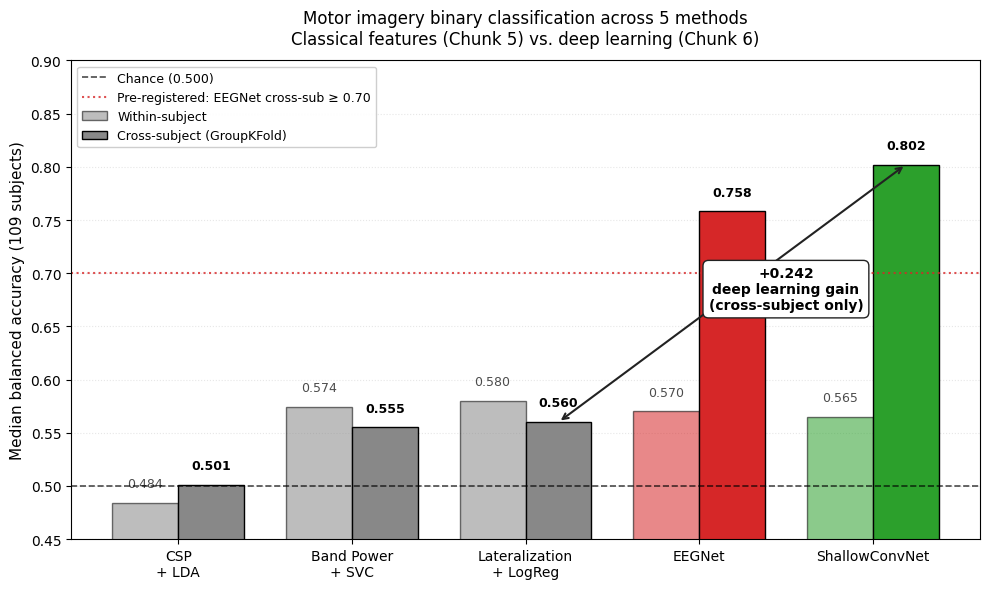

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

methods = ["CSP\n+ LDA", "Band Power\n+ SVC", "Lateralization\n+ LogReg",
           "EEGNet", "ShallowConvNet"]
within_scores = [0.484, 0.574, 0.580, 0.570, 0.565]
cross_scores = [0.501, 0.555, 0.560, 0.758, 0.802]

x = np.arange(len(methods))
width = 0.38

# Bar colors: classical = gray, deep learning = differentiated
classical_color = "#888888"
eegnet_color = "#d62728"
shallow_color = "#2ca02c"

within_colors = [classical_color] * 3 + [eegnet_color, shallow_color]
cross_colors = within_colors

bars1 = ax.bar(x - width/2, within_scores, width, label="Within-subject",
               color=within_colors, alpha=0.55, edgecolor="black", linewidth=1)
bars2 = ax.bar(x + width/2, cross_scores, width, label="Cross-subject (GroupKFold)",
               color=within_colors, alpha=1.0, edgecolor="black", linewidth=1)

# Chance line
ax.axhline(0.5, color="black", linestyle="--", linewidth=1.2, alpha=0.7,
           label="Chance (0.500)")

# Pre-registered threshold for EEGNet cross-subject
ax.axhline(0.70, color="#d62728", linestyle=":", linewidth=1.5, alpha=0.8,
           label="Pre-registered: EEGNet cross-sub ≥ 0.70")

# Annotate values on top of cross bars
for i, val in enumerate(cross_scores):
    ax.text(x[i] + width/2, val + 0.012, f"{val:.3f}", ha="center", va="bottom",
            fontsize=9, fontweight="bold")
for i, val in enumerate(within_scores):
    ax.text(x[i] - width/2, val + 0.012, f"{val:.3f}", ha="center", va="bottom",
            fontsize=9, alpha=0.7)

# Bracket showing the +0.20 gain from classical to DL on cross-subject
ax.annotate(
    "", xy=(2 + width/2, 0.560), xytext=(4 + width/2, 0.802),
    arrowprops=dict(arrowstyle="<->", color="#222222", lw=1.5)
)
ax.text(3.5, 0.685, "+0.242\ndeep learning gain\n(cross-subject only)",
        ha="center", va="center", fontsize=10, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor="#222222", linewidth=1))

ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=10)
ax.set_ylabel("Median balanced accuracy (109 subjects)", fontsize=11)
ax.set_ylim(0.45, 0.90)
ax.set_title("Motor imagery binary classification across 5 methods\n"
             "Classical features (Chunk 5) vs. deep learning (Chunk 6)",
             fontsize=12, pad=12)
ax.legend(loc="upper left", fontsize=9, framealpha=0.95)
ax.grid(axis="y", alpha=0.3, linestyle=":")
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "chunk6_summary.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / 'chunk6_summary.png'}")

In [ ]:
print("Training production ShallowConvNet on all 109 subjects...")

t0 = time.time()
production_clf = TorchEEGClassifier(
    model_name="shallow",
    n_channels=N_CHANNELS,
    n_times=N_TIMES,
    device=DEVICE,
    random_state=RANDOM_STATE,
).set_fold_index(0)

production_clf.fit(X, y)
elapsed = time.time() - t0
print(f"Trained in {elapsed:.1f}s")
print(f"Inner val balanced_accuracy: "
      f"{production_clf.train_result_['best_val_bacc']:.3f}")
print(f"Stopped at epoch: {production_clf.train_result_['stopped_epoch']}")

# %%
# Save weights, normalization stats, and metadata
out_path = RESULTS_DIR / "production_shallowconvnet.pt"
torch.save({
    "state_dict": production_clf.model_.state_dict(),
    "model_name": "shallow",
    "n_channels": N_CHANNELS,
    "n_times": N_TIMES,
    "norm_mean": production_clf.norm_stats_.mean,
    "norm_std": production_clf.norm_stats_.std,
    "training": {
        "architecture": "ShallowConvNet",
        "n_subjects": int(len(np.unique(groups))),
        "n_trials_total": int(len(X)),
        "stopped_epoch": production_clf.train_result_["stopped_epoch"],
        "val_bacc": production_clf.train_result_["best_val_bacc"],
        "cross_subject_median_estimate": 0.802,
        "trained_on_kaggle": True,
        "random_state": RANDOM_STATE,
    },
}, out_path)

print(f"Saved production model: {out_path}")
print(f"File size: {out_path.stat().st_size / 1024:.1f} KB")

# %% [markdown]
# **Quick sanity check.** Predict on the full training set and report
# accuracy. This is *training* accuracy, not held-out — it will be very
# high (~0.95+) and doesn't tell us anything about generalization. We're
# just confirming the saved model loads and runs correctly.

# %%
# Predict and check
preds = production_clf.predict(X)
train_acc = (preds == y).mean()
print(f"Training set accuracy (sanity check, NOT generalization): {train_acc:.3f}")
print(f"  (Generalization estimate from §7: 0.802)")